In [11]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:
# Load Heart Failure Dataset

file_name = "heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [13]:
# Check missing values and duplicates

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Duplicate Rows: 0


In [14]:
# Target distribution
print("Target Distribution:")
print(df["DEATH_EVENT"].value_counts())

print("\nTarget Percentage:")
print(df["DEATH_EVENT"].value_counts(normalize=True) * 100)

# Features and target
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

Target Distribution:
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Target Percentage:
DEATH_EVENT
0    67.892977
1    32.107023
Name: proportion, dtype: float64

Features shape: (299, 12)
Target shape: (299,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 12)
Testing data: (60, 12)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 12)
Testing data: (60, 12)


## 4. Feature Scaling

Feature scaling is applied to standardize the numerical features.
StandardScaler transforms the features so that they have a mean of 0
and a standard deviation of 1.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Scaling completed successfully!
Training shape: (239, 12)
Testing shape: (60, 12)


## 5. Handling Class Imbalance Using SMOTE

The target classes are imbalanced, with fewer death-event cases than non-death cases.
SMOTE is applied to the training data to balance the minority class.
The testing data remains unchanged for unbiased model evaluation.

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nNew training shape:", X_train_smote.shape)

Before SMOTE:
DEATH_EVENT
0    162
1     77
Name: count, dtype: int64

After SMOTE:
DEATH_EVENT
0    162
1    162
Name: count, dtype: int64

New training shape: (324, 12)


## 6. Classification Models

Multiple classification algorithms are implemented to predict the DEATH_EVENT.
Their performance is evaluated using Accuracy, Precision, Recall and F1-Score.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    
    y_pred = model.predict(X_test_scaled)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

print("Model Comparison:")
display(results_df.round(3))

Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.800,0.733,0.579,0.647
1,Decision Tree,0.783,0.625,0.789,0.698
2,Random Forest,0.817,0.722,0.684,0.703
3,KNN,0.750,0.611,0.579,0.595


## 7. Random Forest Optimization Using GridSearchCV

Random Forest achieved the best overall performance among the tested models.
GridSearchCV is used to find the best combination of hyperparameters and improve
the performance of the Random Forest classifier.

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_, 3))

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation Accuracy:
0.892


## 8. Final Optimized Model Evaluation

The best Random Forest model obtained from GridSearchCV is evaluated on the
unseen testing data using Accuracy, Precision, Recall and F1-Score.

In [23]:
# Get best model
best_rf = grid_search.best_estimator_

# Predictions
y_pred_final = best_rf.predict(X_test_scaled)

# Performance metrics
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print("Final Optimized Random Forest Performance")
print("=" * 50)
print(f"Accuracy  : {final_accuracy:.3f}")
print(f"Precision : {final_precision:.3f}")
print(f"Recall    : {final_recall:.3f}")
print(f"F1-Score  : {final_f1:.3f}")

Final Optimized Random Forest Performance
Accuracy  : 0.817
Precision : 0.700
Recall    : 0.737
F1-Score  : 0.718


## 9. Classification Report

The classification report provides detailed performance measures for both
classes of the target variable.

In [24]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred_final))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        41
           1       0.70      0.74      0.72        19

    accuracy                           0.82        60
   macro avg       0.79      0.80      0.79        60
weighted avg       0.82      0.82      0.82        60



## 10. Confusion Matrix

The confusion matrix is used to visualize the correct and incorrect
predictions made by the final optimized model.

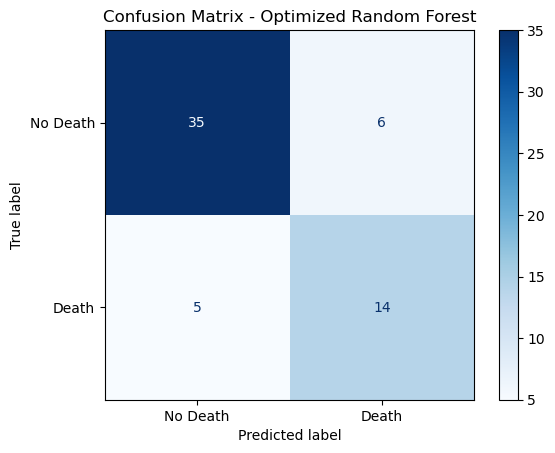

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Death", "Death"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Optimized Random Forest")
plt.show()

## 11. Final Performance Visualization

The performance metrics of the final optimized Random Forest model are
visualized using a bar chart.

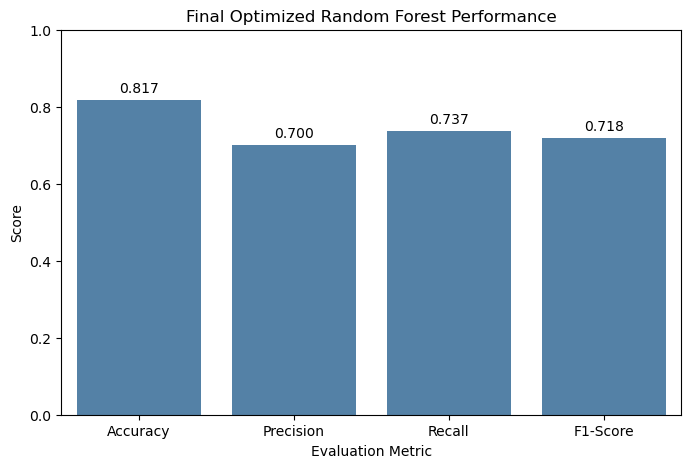

In [26]:
final_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Metric",
    y="Score",
    data=final_summary,
    color="steelblue"
)

plt.ylim(0, 1)
plt.title("Final Optimized Random Forest Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

for i, score in enumerate(final_summary["Score"]):
    plt.text(i, score + 0.02, f"{score:.3f}", ha="center")

plt.show()

## 12. Final Conclusion

The Heart Failure Clinical Records dataset was successfully preprocessed
without missing values or duplicate records. Feature scaling was performed
using StandardScaler and class imbalance was addressed using SMOTE.

Multiple classification algorithms were implemented and compared using
Accuracy, Precision, Recall and F1-Score. Among the evaluated models,
Random Forest achieved the best overall performance.

The Random Forest model was further optimized using GridSearchCV.
The optimized model was evaluated using Accuracy, Precision, Recall,
F1-Score, Classification Report and Confusion Matrix.

Overall, the optimized Random Forest model provides the final classification
performance for predicting the DEATH_EVENT outcome.